In [3]:
!pip install numpy sympy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
print(sys.executable)

C:\Users\pansogan\AppData\Local\Programs\Python\Python313\python.exe


## **1. Systems of linear equations**


Menghitung dan mempelajari solusi dari persamaan, serta sistem persamaan, tanpa diragukan lagi memainkan peran penting dalam matematika; meskipun perlu segera kami tambahkan bahwa itu bukanlah satu-satunya hal yang dilakukan oleh para matematikawan! Dalam bab ini kita akan mengembangkan suatu teori yang pada dasarnya lengkap mengenai keluarga persamaan matematika yang cukup sederhana: yaitu, persamaan linear. Hal ini akan menjadi pengantar yang agak tidak langsung menuju studi kita tentang aljabar linear, karena di balik deskripsi parametrik dari solusi sistem linear tersembunyi konsep-konsep ruang vektor seperti subruang, bentangan (span), dan kebebasan linear. Selain itu, kita juga akan mempelajari salah satu alat komputasi terpenting dalam aljabar linear: eliminasi Gauss (Gaussian elimination).

## **1.2Sistem Persamaan Linear**

### Definisi (Persamaan Linear)

Suatu **ekspresi linear** dalam $n$ peubah (atau variabel) $x_1, x_2, \ldots, x_n$ adalah ekspresi yang berbentuk

$$
a_1 x_1 + a_2 x_2 + \cdots + a_n x_n,
$$

dengan $a_1, a_2, \ldots, a_n$ adalah bilangan real tetap (konstanta).

---

Suatu **persamaan linear** dalam peubah $x_1, x_2, \ldots, x_n$ adalah persamaan yang dapat disederhanakan (hanya menggunakan operasi penjumlahan dan pengurangan) ke bentuk

$$
a_1 x_1 + a_2 x_2 + \cdots + a_n x_n = b
\tag{1.1.1}
$$

Bentuk ini disebut sebagai **bentuk standar**.

---

Suatu persamaan dalam peubah $x_1, x_2, \ldots, x_n$ disebut **nonlinear** apabila tidak dapat disederhanakan ke bentuk (1.1.1) hanya dengan menggunakan penjumlahan dan pengurangan.

---

Diberikan persamaan linear dalam bentuk standar (1.1.1):

- Persamaan disebut **homogen** jika $b = 0$.
- Persamaan disebut **nonhomogen** jika $b \ne 0$.

## **1.3Definisi Sistem persamaan linear**

**Sistem persamaan linear** (atau **sistem linear**) adalah himpunan persamaan linear.

Sistem linear **homogen** adalah himpunan persamaan linear homogen.

Ketika menampilkan sistem $m$ persamaan dalam $n$ variabel tak diketahui $x_1, x_2, \ldots, x_n$, kita biasanya menulis setiap persamaan dalam bentuk standar dan menyelaraskan suku-suku yang bersesuaian dari setiap persamaan ke dalam kolom:

$$
\begin{aligned}
a_{11}x_1 & \quad + \quad a_{12}x_2 & \quad + \cdots + \quad a_{1n}x_n & \quad = \quad b_1 \\
a_{21}x_1 & \quad + \quad a_{22}x_2 & \quad + \cdots + \quad a_{2n}x_n & \quad = \quad b_2 \\
& \quad \vdots & \quad \vdots & \quad \vdots \\
a_{m1}x_1 & \quad + \quad a_{m2}x_2 & \quad + \cdots + \quad a_{mn}x_n & \quad = \quad b_m
\end{aligned}
$$

Sebuah sistem homogen dengan demikian biasanya ditulis sebagai:

$$
\begin{aligned}
a_{11}x_1 & \quad + \quad a_{12}x_2 & \quad + \cdots + \quad a_{1n}x_n & \quad = \quad 0 \\
a_{21}x_1 & \quad + \quad a_{22}x_2 & \quad + \cdots + \quad a_{2n}x_n & \quad = \quad 0 \\
& \quad \vdots & \quad \vdots & \quad \vdots \\
a_{m1}x_1 & \quad + \quad a_{m2}x_2 & \quad + \cdots + \quad a_{mn}x_n & \quad = \quad 0
\end{aligned}
$$

In [4]:
import numpy as np

class SistemPersamaanLinear:
    def __init__(self, A, b):
        self.A = np.array(A, dtype=float)
        self.b = np.array(b, dtype=float)
        self.m, self.n = self.A.shape

    def tampilkan(self):
        print("\nSistem Persamaan Linear")
        print("-" * 40)
        for i in range(self.m):
            persamaan = []
            for j in range(self.n):
                koef = self.A[i, j]
                if koef != 0:
                    if koef == 1:
                        persamaan.append(f"x{j+1}")
                    elif koef == -1:
                        persamaan.append(f"-x{j+1}")
                    else:
                        persamaan.append(f"{koef}x{j+1}")
            kiri = " + ".join(persamaan).replace("+ -", "- ")
            print(f"{kiri} = {self.b[i]}")
        print("-" * 40)

    def info(self):
        print("\nInformasi Sistem")
        print("-" * 40)
        print("Jumlah persamaan :", self.m)
        print("Jumlah variabel  :", self.n)
        print("Rank matriks     :", np.linalg.matrix_rank(self.A))

        if self.m == self.n:
            det = np.linalg.det(self.A)
            print("Determinan       :", round(det, 4))
            if abs(det) > 1e-10:
                print("Kesimpulan       : Solusi unik")
            else:
                print("Kesimpulan       : Tidak unik")
        print("-" * 40)

    def solve(self):
        try:
            if self.m == self.n:
                x = np.linalg.solve(self.A, self.b)
            else:
                x = np.linalg.lstsq(self.A, self.b, rcond=None)[0]
            return x
        except:
            return None


# ==============================
# CONTOH PROGRAM
# ==============================

print("=" * 50)
print("PROGRAM SISTEM PERSAMAAN LINEAR")
print("=" * 50)

A = [
    [2, 1, -1],
    [-3, -1, 2],
    [-2, 1, 2]
]

b = [8, -11, -3]

sistem = SistemPersamaanLinear(A, b)

sistem.tampilkan()
sistem.info()

solusi = sistem.solve()

print("\nSolusi:")
if solusi is not None:
    for i, nilai in enumerate(solusi):
        print(f"x{i+1} = {round(nilai, 4)}")
else:
    print("Sistem tidak memiliki solusi unik")

print("=" * 50)

PROGRAM SISTEM PERSAMAAN LINEAR

Sistem Persamaan Linear
----------------------------------------
2.0x1 + x2 - x3 = 8.0
-3.0x1 - x2 + 2.0x3 = -11.0
-2.0x1 + x2 + 2.0x3 = -3.0
----------------------------------------

Informasi Sistem
----------------------------------------
Jumlah persamaan : 3
Jumlah variabel  : 3
Rank matriks     : 3
Determinan       : -1.0
Kesimpulan       : Solusi unik
----------------------------------------

Solusi:
x1 = 2.0
x2 = 3.0
x3 = -1.0


## **1.4Solusi sistem persamaan linear**

## Solusi persamaan linear

**Solusi persamaan linear**

$$a_1x_1 + a_2x_2 + \cdots + a_nx_n = b$$

adalah $n$-tupel $(s_1, s_2, \ldots, s_n)$ bilangan real yang membuat penugasan variabel $x_1 = s_1, x_2 = s_2, \ldots, x_n = s_n$ memenuhi persamaan. Kita katakan $(s_1, \ldots, s_n)$ **menyelesaikan persamaan** dalam kasus ini.

## Solusi sistem persamaan linear

**Solusi sistem persamaan linear**

$$
\begin{aligned}
a_{11}x_1 & \quad + \quad a_{12}x_2 & \quad + \cdots + \quad a_{1n}x_n & \quad = \quad b_1 \\
a_{21}x_1 & \quad + \quad a_{22}x_2 & \quad + \cdots + \quad a_{2n}x_n & \quad = \quad b_2 \\
& \quad \vdots & \quad \vdots & \quad \vdots \\
a_{m1}x_1 & \quad + \quad a_{m2}x_2 & \quad + \cdots + \quad a_{mn}x_n & \quad = \quad b_m
\end{aligned}
$$

adalah $n$-tupel $(s_1, s_2, \ldots, s_n)$ yang merupakan solusi untuk setiap $m$ persamaan dalam sistem. Kita katakan $(s_1, s_2, \ldots, s_n)$ **menyelesaikan sistem** dalam kasus ini.

## Jenis-Jenis Himpunan Solusi

Diberikan sistem linear, kita mencari himpunan **semua** solusi sistem. Himpunan solusi ini akan memiliki salah satu dari tiga bentuk kualitatif:

1. **Himpunan solusi kosong** (tidak ada solusi). Kita katakan sistem **inkonsisten**. Jika tidak, sistem disebut **konsisten**.

2. **Himpunan solusi mengandung satu elemen** (tepat satu solusi).

3. **Himpunan solusi mengandung tak hingga banyak elemen** (tak hingga banyak solusi).

## **Contoh 1.5 Solusi sistem elementer**

Untuk setiap sistem, hitung himpunan solusinya.

## Sistem 1
$$
\begin{aligned}
x - y &= 0 \\
x - y &= 1
\end{aligned}
$$

## Sistem 2
$$
\begin{aligned}
x - y &= 0 \\
x + y &= 1
\end{aligned}
$$

## Sistem 3
$$
\begin{aligned}
x - y &= 1 \\
2x - 2y &= 2
\end{aligned}
$$

## Solusi

### Sistem 1: **Tidak Ada Solusi (Inkonsisten)**
Persamaan $x - y = 0$ dan $x - y = 1$ bertentangan. Ekspresi yang sama tidak bisa sama dengan 0 dan 1 secara bersamaan.
- **Himpunan solusi:** $\emptyset$ (himpunan kosong)
- **Klasifikasi:** Sistem inkonsisten

### Sistem 2: **Solusi Unik**
Menjumlahkan persamaan:
- $(x - y) + (x + y) = 0 + 1$
- $2x = 1$
- $x = \frac{1}{2}$

Substitusi kembali:
- $\frac{1}{2} - y = 0$
- $y = \frac{1}{2}$

- **Himpunan solusi:** $\left\{\left(\frac{1}{2}, \frac{1}{2}\right)\right\}$
- **Klasifikasi:** Konsisten dengan solusi unik

### Sistem 3: **Tak Hingga Banyak Solusi**
Persamaan kedua adalah 2 kali persamaan pertama:
- $2x - 2y = 2$ ekuivalen dengan $x - y = 1$

Misalkan $y = t$ (parameter bebas), maka:
- $x = 1 + t$

- **Himpunan solusi:** $\{(1+t, t) : t \in \mathbb{R}\}$
- **Klasifikasi:** Konsisten dengan tak hingga banyak solusi

---

## Interpretasi Geometris

Persamaan linear (nontrivial) dalam dua variabel tak diketahui mendefinisikan sebuah **garis di $\mathbb{R}^2$**, dan persamaan (nontrivial) dalam tiga variabel tak diketahui mendefinisikan sebuah **bidang di $\mathbb{R}^3$**.

Observasi ini memungkinkan kita membawa intuisi geometris yang kuat untuk analisis sistem persamaan linear dalam dua atau tiga variabel tak diketahui.

In [12]:
import numpy as np

print("=" * 50)
print("EXAMPLE 1.1.6 - PERHITUNGAN SOLUSI")
print("=" * 50)

# ===== SYSTEM 1: x - y = 0, x - y = 1 =====
print("\n[SYSTEM 1]")
print("  x - y = 0")
print("  x - y = 1")

A1 = np.array([[1, -1], [1, -1]])
b1 = np.array([0, 1])

rank_A = np.linalg.matrix_rank(A1)
rank_Ab = np.linalg.matrix_rank(np.column_stack([A1, b1]))

if rank_A != rank_Ab:
    print(f"  → Hasil: TIDAK ADA SOLUSI (inkonsisten)")
else:
    solusi = np.linalg.lstsq(A1, b1, rcond=None)[0]
    print(f"  → Solusi: x = {solusi[0]:.4f}, y = {solusi[1]:.4f}")


# ===== SYSTEM 2: x - y = 0, x + y = 1 =====
print("\n[SYSTEM 2]")
print("  x - y = 0")
print("  x + y = 1")

A2 = np.array([[1, -1], [1, 1]])
b2 = np.array([0, 1])

try:
    solusi2 = np.linalg.solve(A2, b2)
    print(f"  → Hasil: SOLUSI UNIK")
    print(f"  → x = {solusi2[0]:.4f} (= 1/2)")
    print(f"  → y = {solusi2[1]:.4f} (= 1/2)")
except:
    print("  → Tidak dapat diselesaikan")


# ===== SYSTEM 3: x - y = 1, 2x - 2y = 2 =====
print("\n[SYSTEM 3]")
print("  x - y = 1")
print("  2x - 2y = 2")

A3 = np.array([[1, -1], [2, -2]])
b3 = np.array([1, 2])

rank_A3 = np.linalg.matrix_rank(A3)
rank_Ab3 = np.linalg.matrix_rank(np.column_stack([A3, b3]))

if rank_A3 == rank_Ab3 and rank_A3 < 2:
    print(f"  → Hasil: TAK HINGGA SOLUSI")
    print(f"  → Bentuk umum: x = 1 + t, y = t (t ∈ ℝ)")
    print(f"  → Contoh solusi:")
    for t in [-1, 0, 1]:
        print(f"     t = {t}: x = {1+t}, y = {t}")
else:
    print("  → Sistem inkonsisten")


# ===== RINGKASAN =====
print("\n" + "=" * 50)
print("RINGKASAN:")
print("  System 1: Tidak ada solusi")
print("  System 2: Solusi unik → (1/2, 1/2)")
print("  System 3: Tak hingga solusi → (1+t, t)")
print("=" * 50)

EXAMPLE 1.1.6 - PERHITUNGAN SOLUSI

[SYSTEM 1]
  x - y = 0
  x - y = 1
  → Hasil: TIDAK ADA SOLUSI (inkonsisten)

[SYSTEM 2]
  x - y = 0
  x + y = 1
  → Hasil: SOLUSI UNIK
  → x = 0.5000 (= 1/2)
  → y = 0.5000 (= 1/2)

[SYSTEM 3]
  x - y = 1
  2x - 2y = 2
  → Hasil: TAK HINGGA SOLUSI
  → Bentuk umum: x = 1 + t, y = t (t ∈ ℝ)
  → Contoh solusi:
     t = -1: x = 0, y = -1
     t = 0: x = 1, y = 0
     t = 1: x = 2, y = 1

RINGKASAN:
  System 1: Tidak ada solusi
  System 2: Solusi unik → (1/2, 1/2)
  System 3: Tak hingga solusi → (1+t, t)


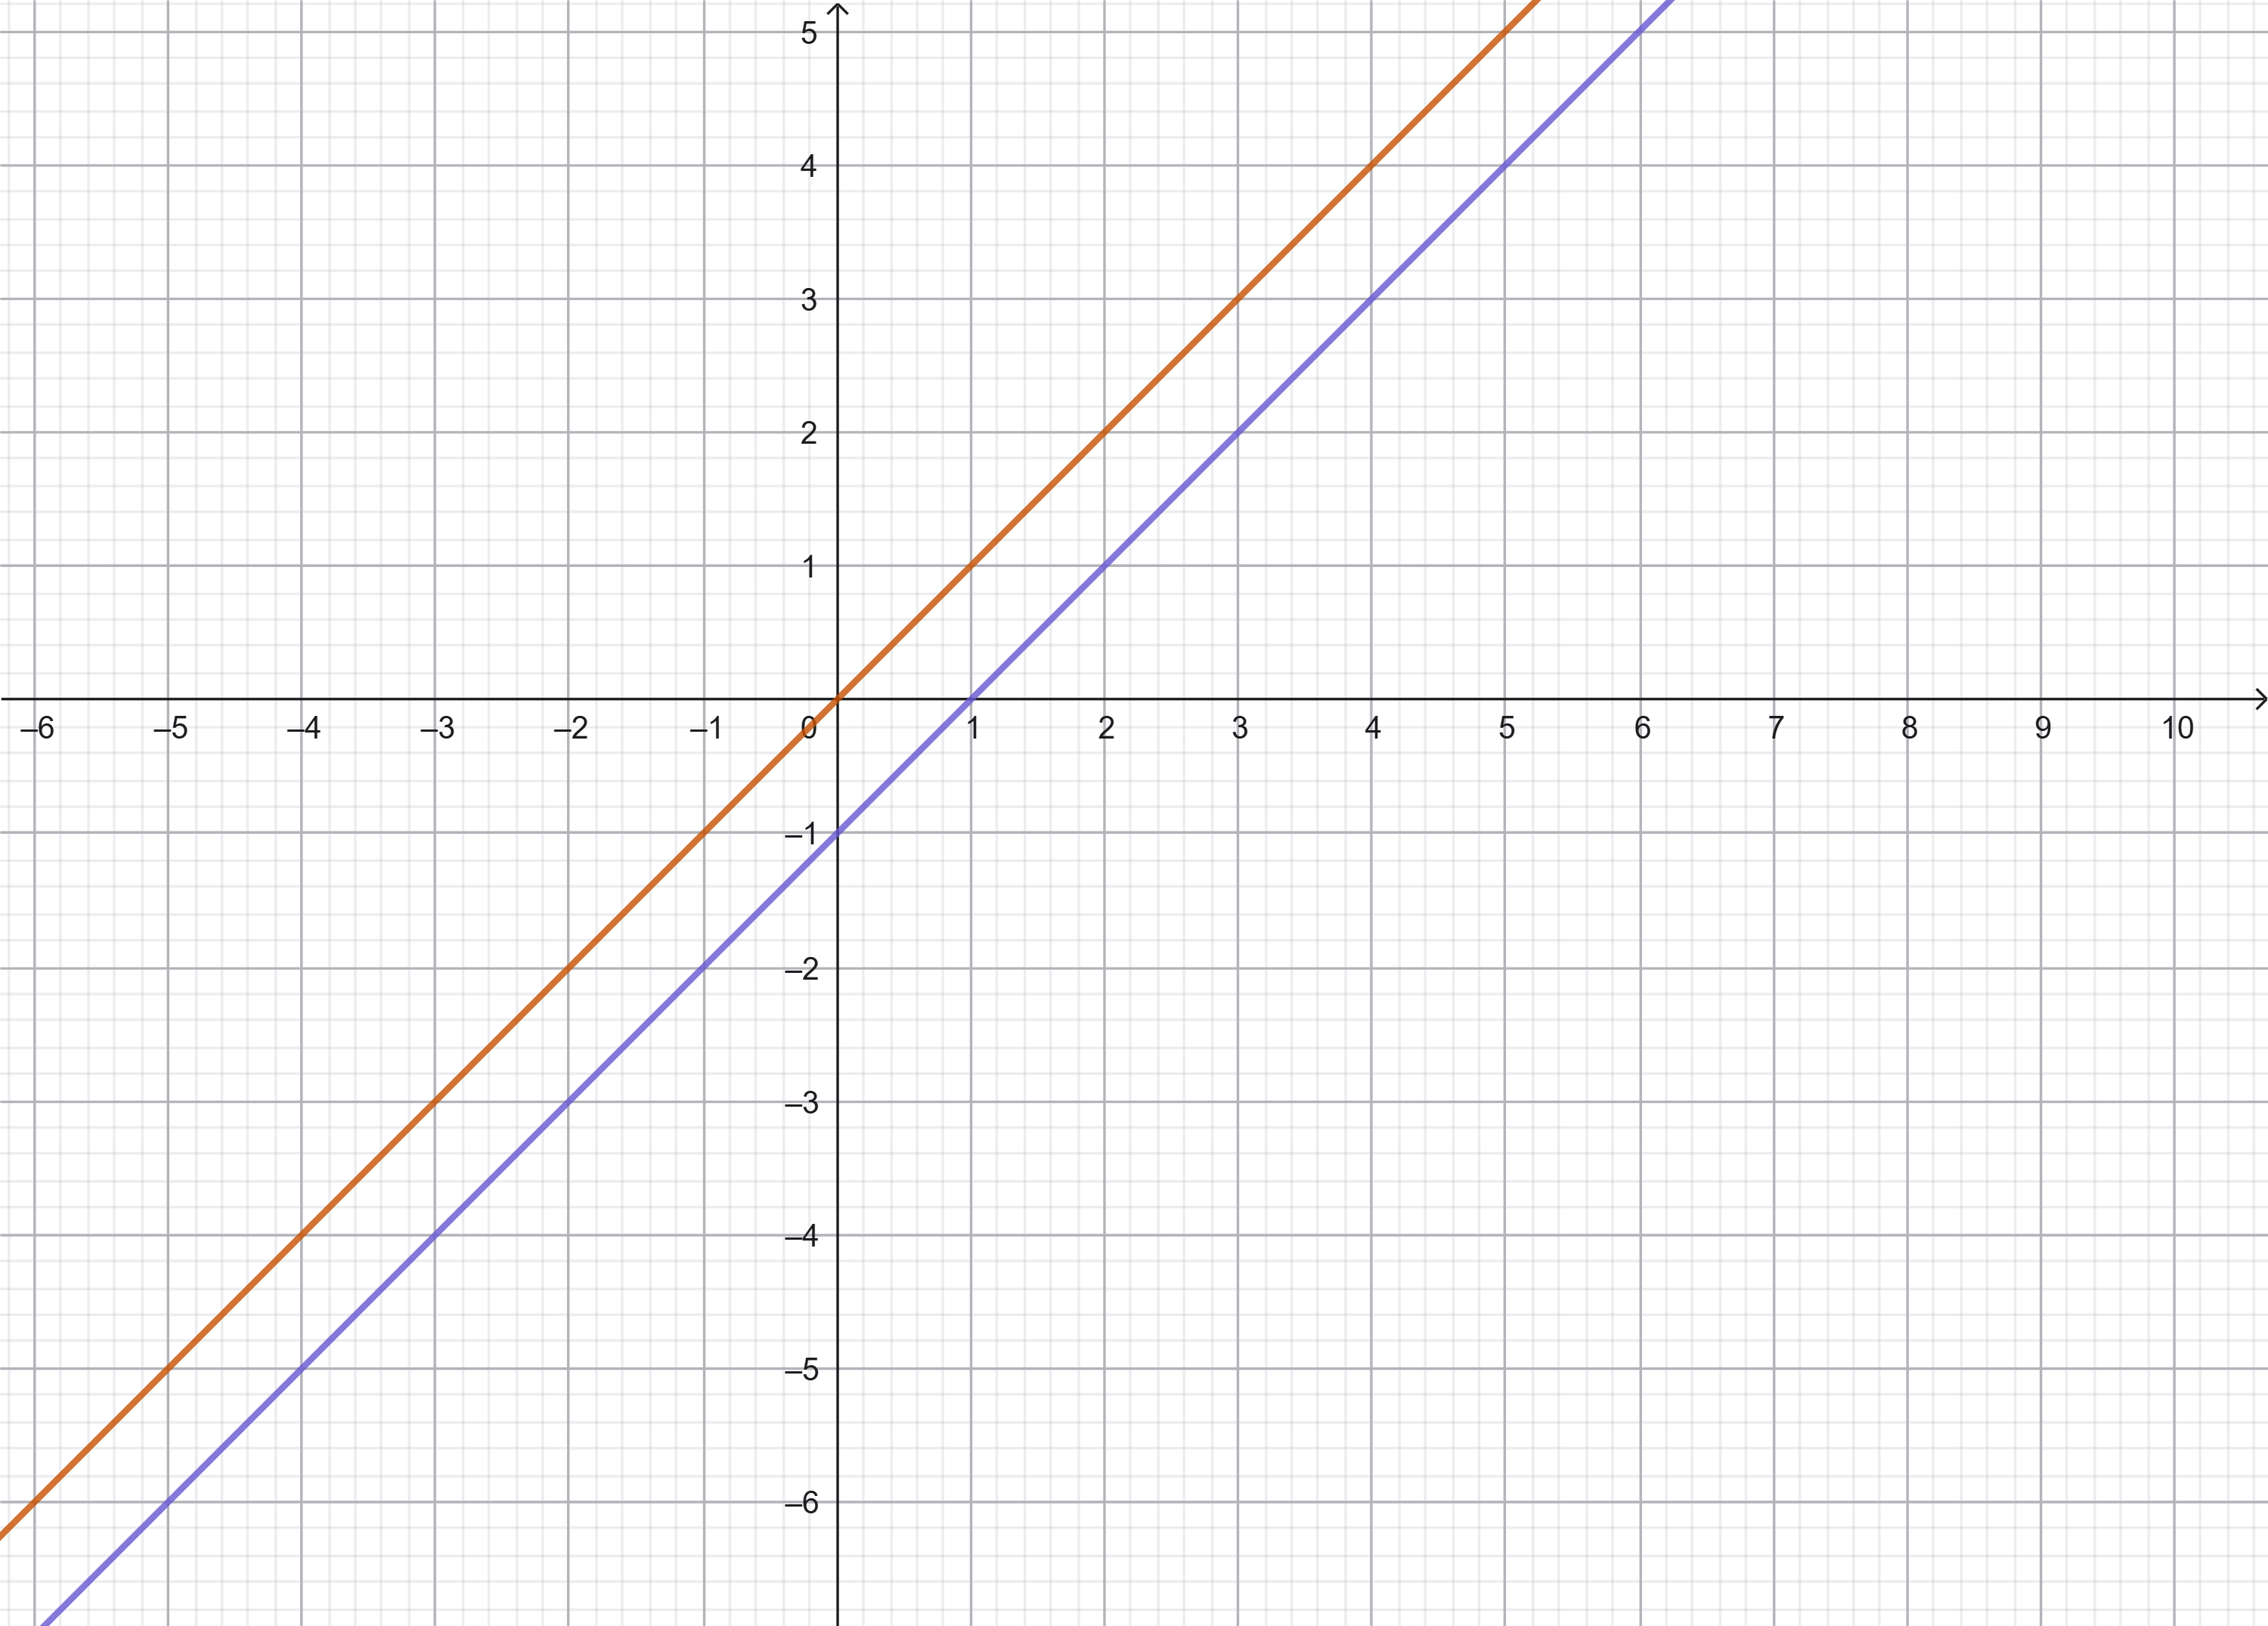

In [22]:
#Geogebra Sytem 1
from IPython.display import Image
Image("geogebraT2.png")

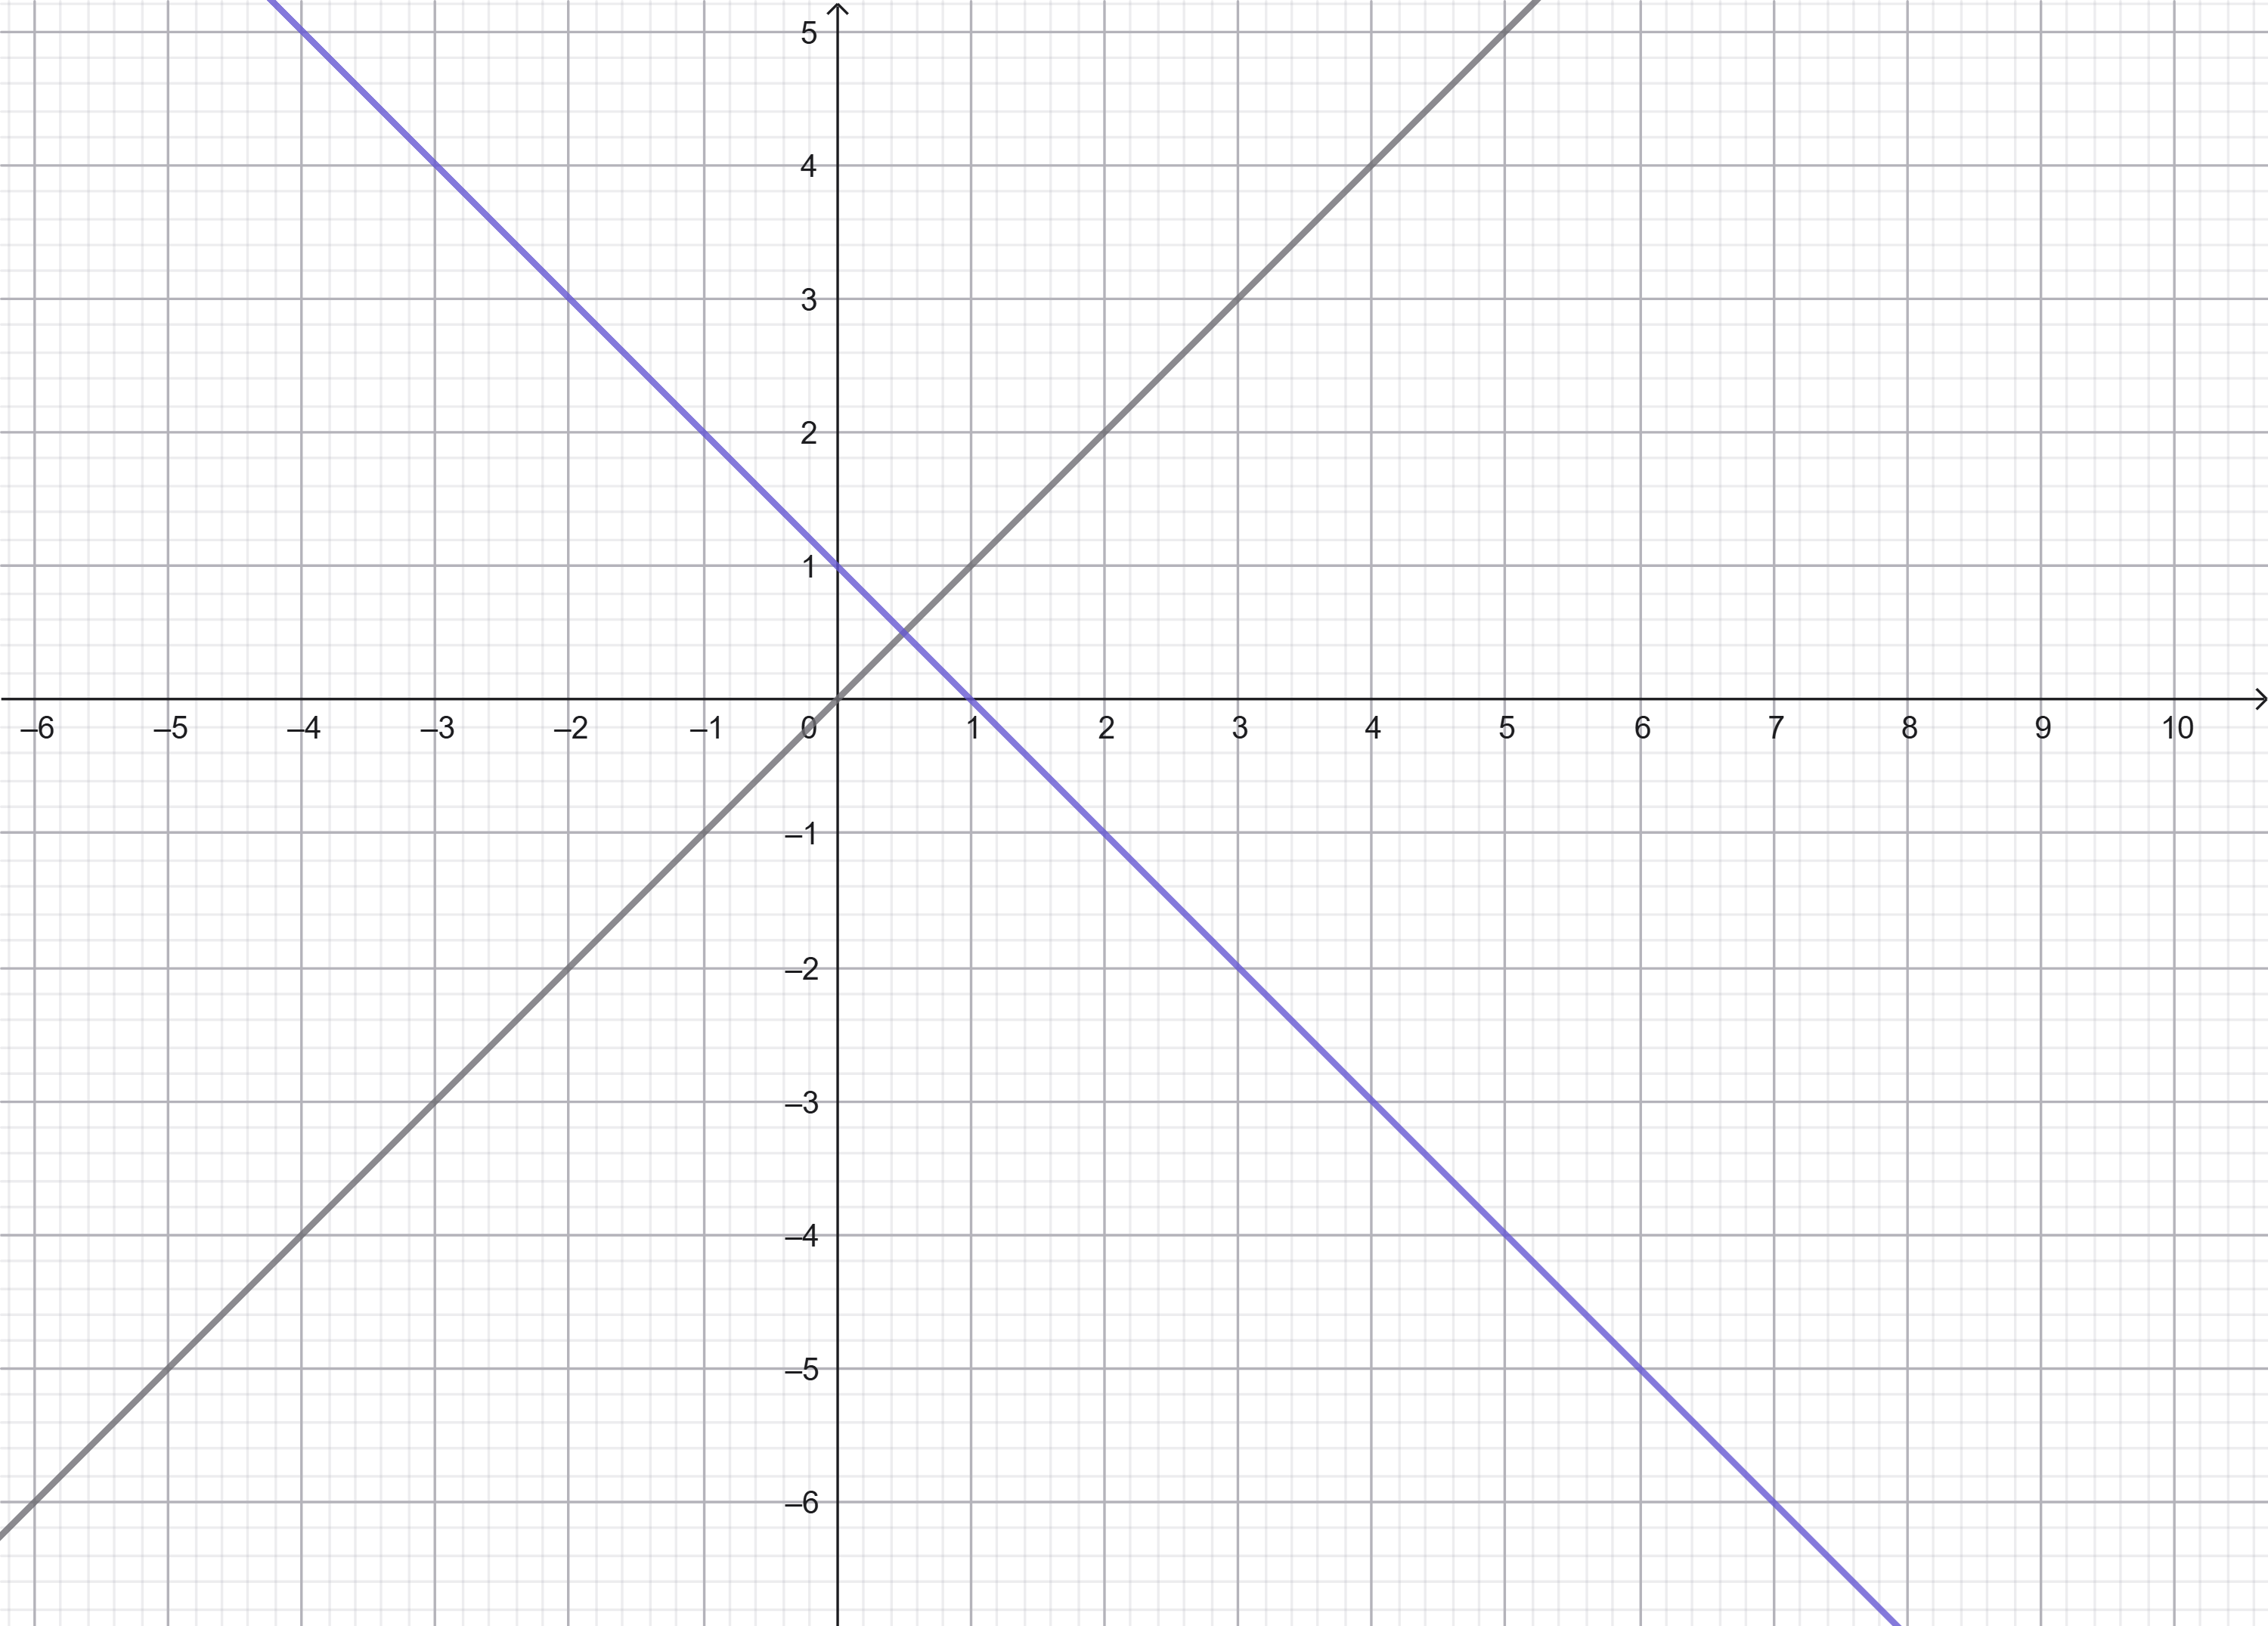

In [21]:
#Geogebra Sytem 2
from IPython.display import Image
Image("geogebraT3.png")

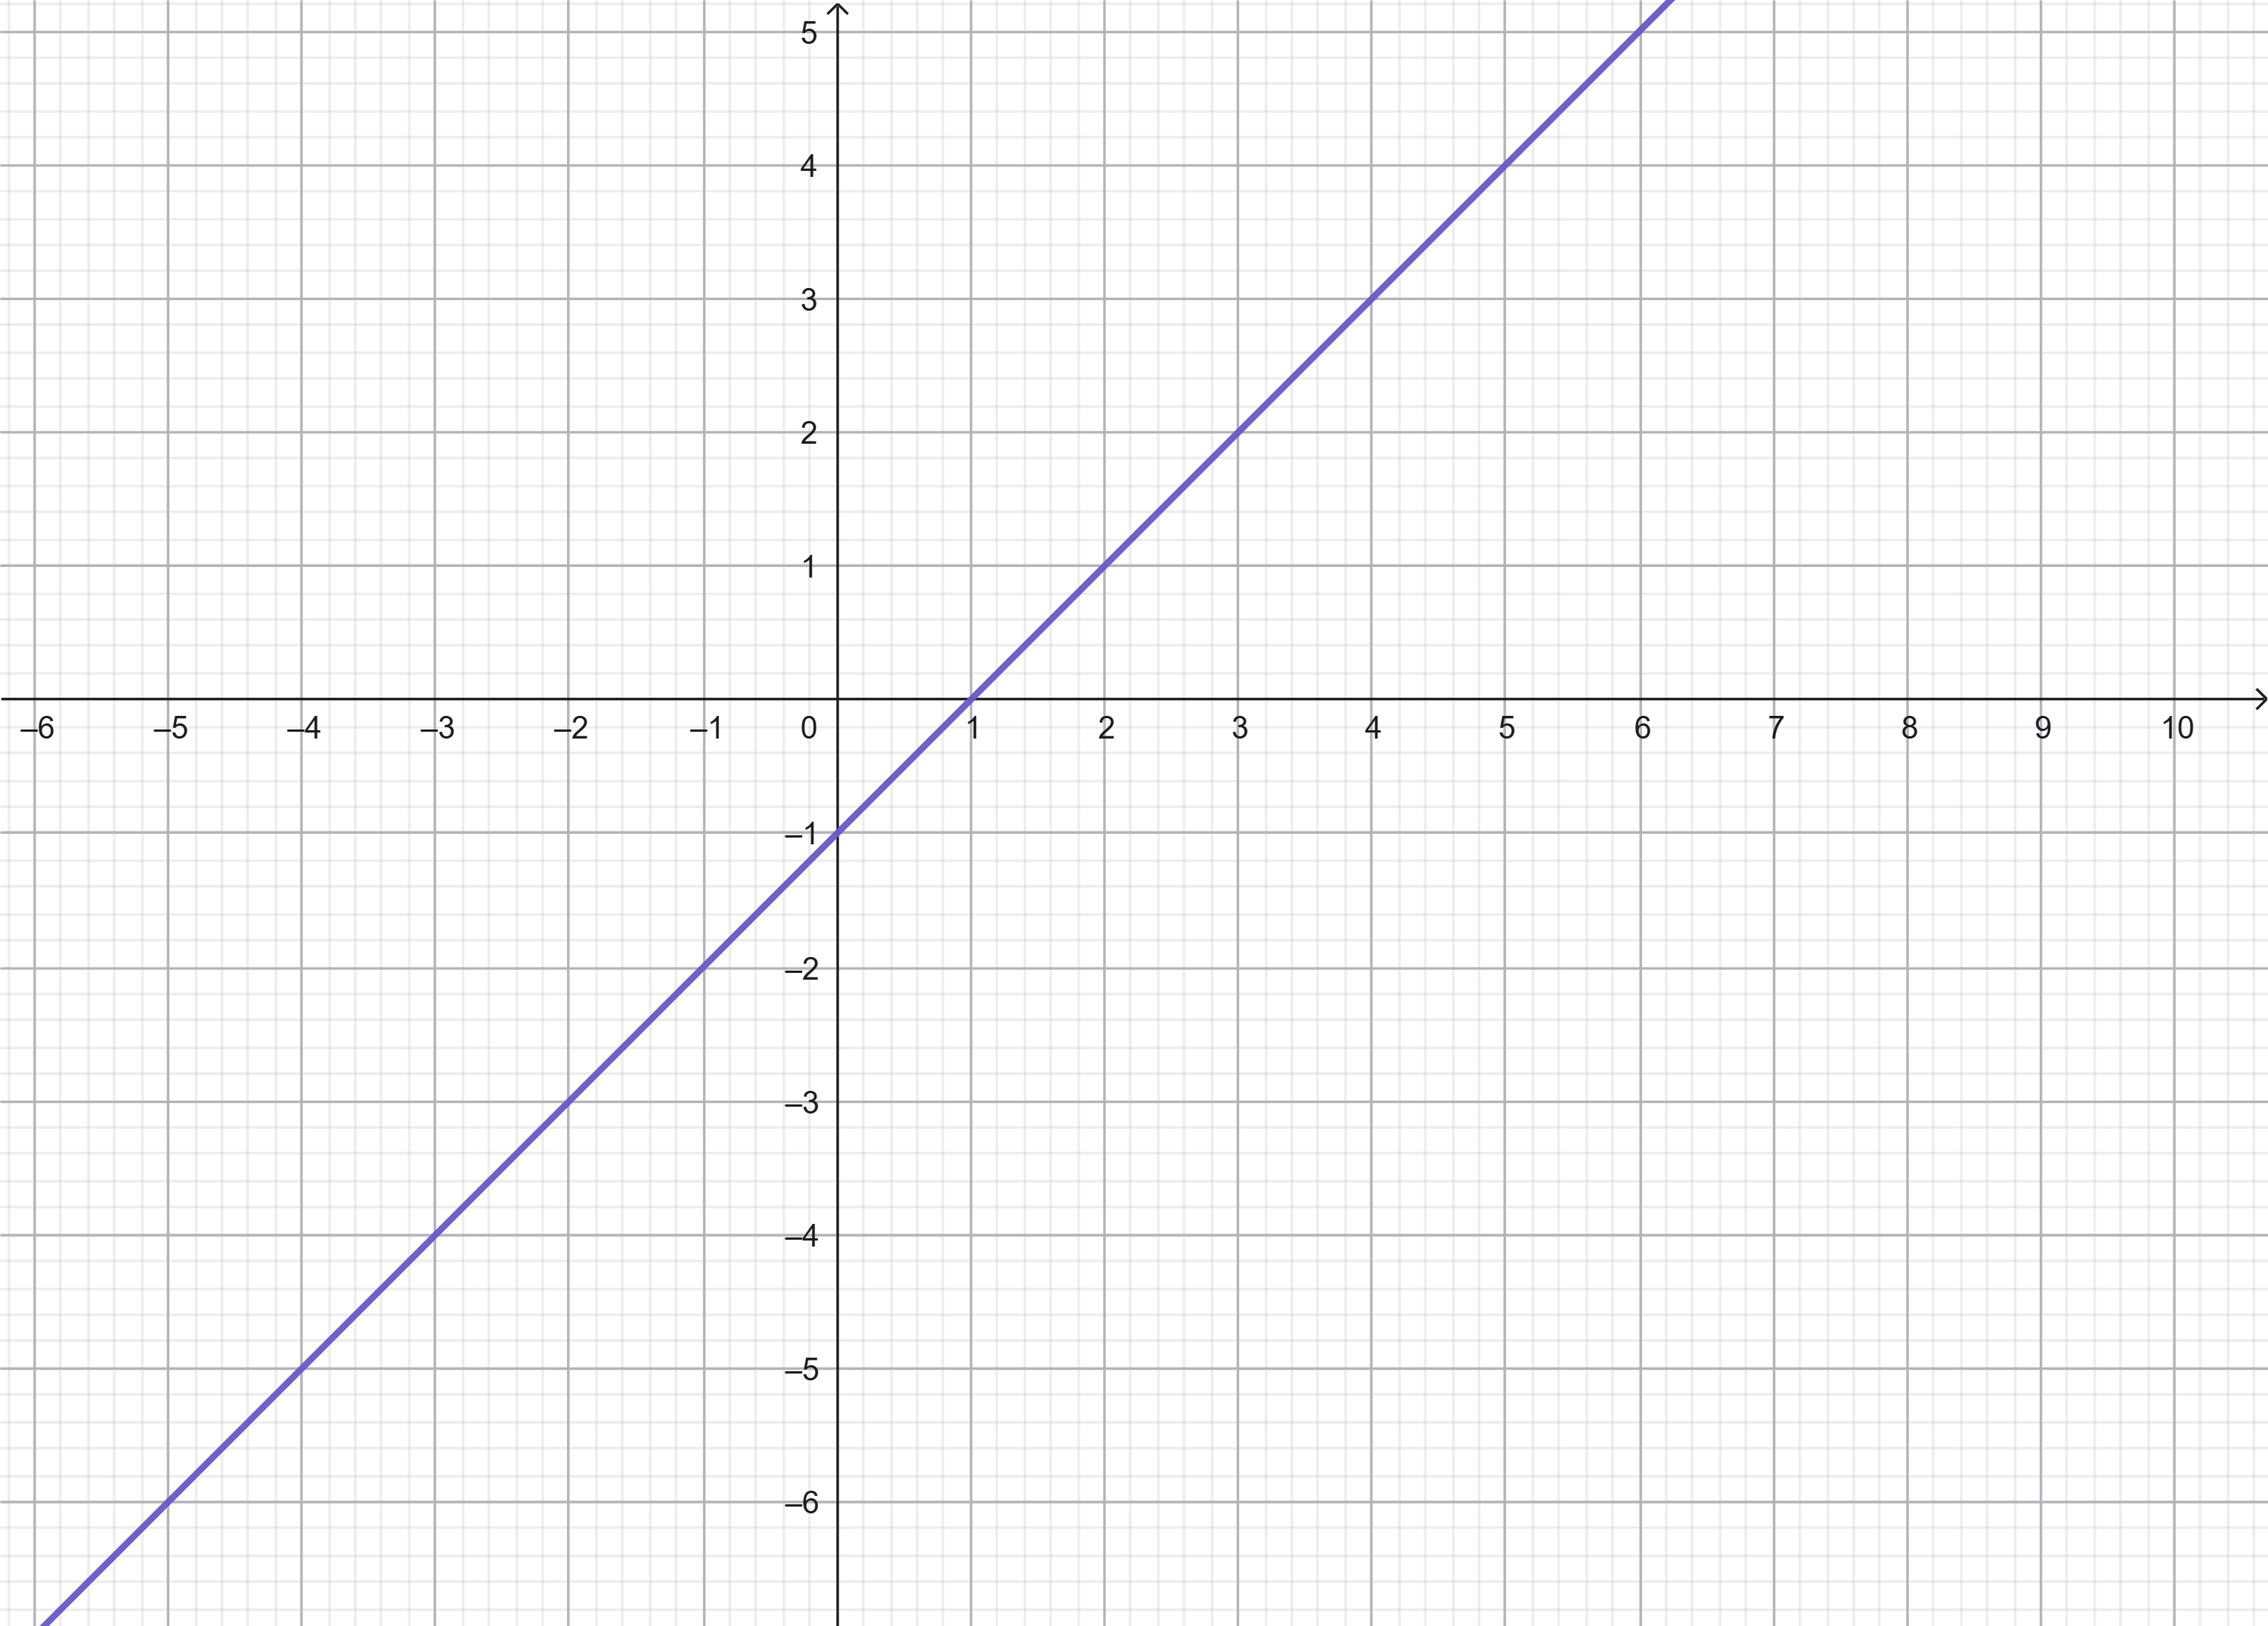

In [20]:
#Geogebra Sytem 3
from IPython.display import Image
Image("geogebraT4.png")

### **Contoh Yang menngunakan 3 variabel dengan kondisi unik**

In [17]:
import numpy as np

print("=" * 50)
print("SISTEM 3 VARIABEL - SOLUSI UNIK")
print("=" * 50)

# Sistem persamaan:
# x + y + z = 6
# 2x - y + z = 3
# x + 2y - z = 2

print("\nSistem Persamaan:")
print("  x + y + z = 6")
print("  2x - y + z = 3")
print("  x + 2y - z = 2")

# Matriks koefisien dan konstanta
A = np.array([
    [1, 1, 1],
    [2, -1, 1],
    [1, 2, -1]
])

b = np.array([6, 3, 2])

# Hitung determinan
det = np.linalg.det(A)
print(f"\nDeterminan matriks A: {det:.4f}")

if abs(det) > 1e-10:
    print("✓ Determinan ≠ 0 → Solusi unik ada!")
    
    # Selesaikan sistem
    solusi = np.linalg.solve(A, b)
    
    print("\n" + "=" * 50)
    print("HASIL:")
    print("=" * 50)
    print(f"  x = {solusi[0]:.4f}")
    print(f"  y = {solusi[1]:.4f}")
    print(f"  z = {solusi[2]:.4f}")
    
    # Verifikasi
    print("\n" + "=" * 50)
    print("VERIFIKASI:")
    print("=" * 50)
    x, y, z = solusi
    print(f"  Persamaan 1: {x:.0f} + {y:.0f} + {z:.0f} = {x+y+z:.0f} (harus 6)")
    print(f"  Persamaan 2: 2({x:.0f}) - {y:.0f} + {z:.0f} = {2*x-y+z:.0f} (harus 3)")
    print(f"  Persamaan 3: {x:.0f} + 2({y:.0f}) - {z:.0f} = {x+2*y-z:.0f} (harus 2)")
    
else:
    print("✗ Determinan = 0 → Tidak ada solusi unik")

print("\n" + "=" * 50)

SISTEM 3 VARIABEL - SOLUSI UNIK

Sistem Persamaan:
  x + y + z = 6
  2x - y + z = 3
  x + 2y - z = 2

Determinan matriks A: 7.0000
✓ Determinan ≠ 0 → Solusi unik ada!

HASIL:
  x = 1.0000
  y = 2.0000
  z = 3.0000

VERIFIKASI:
  Persamaan 1: 1 + 2 + 3 = 6 (harus 6)
  Persamaan 2: 2(1) - 2 + 3 = 3 (harus 3)
  Persamaan 3: 1 + 2(2) - 3 = 2 (harus 2)



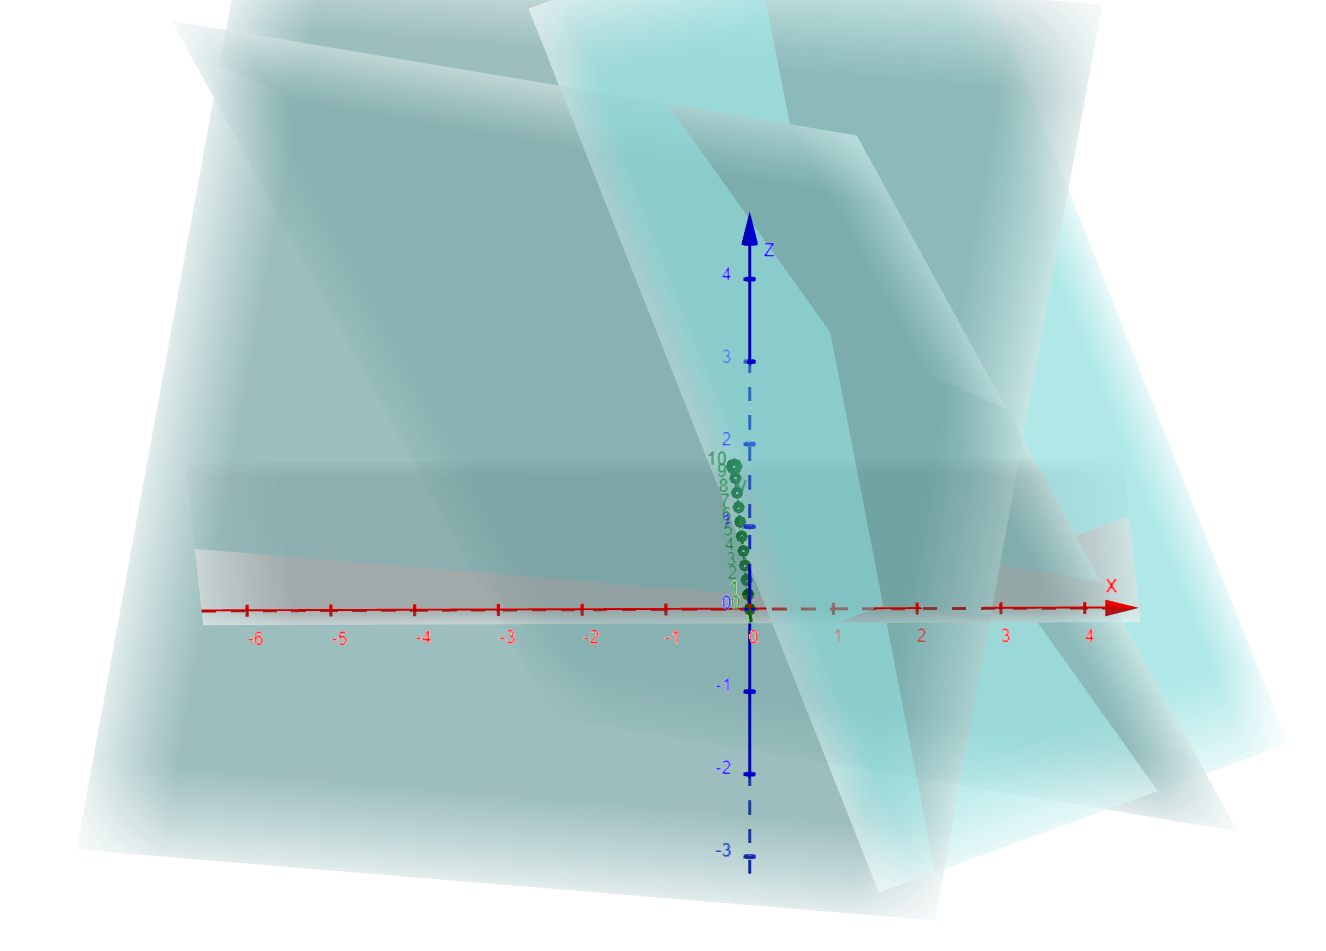

In [19]:
#Geogebra
from IPython.display import Image
Image("geogebraT5.png")

## **2.1 Eliminasi Gauss (Gaussian Elimination)**

Pada Bagian 1.1 kita telah menguraikan sebuah prosedur untuk menyelesaikan suatu **sistem persamaan linear**.  
Prosedur tersebut melibatkan penerapan serangkaian **operasi baris elementer** pada sistem tersebut untuk memperoleh sistem yang lebih *sederhana*.

Pada dua bagian berikutnya, kita akan melengkapi uraian tersebut. Secara khusus, kita akan:

1. Menjelaskan secara tepat apa yang dimaksud dengan sistem yang “lebih sederhana”.
2. Memberikan sebuah algoritma (atau langkah-langkah sistematis) yang menentukan urutan operasi baris apa saja yang harus diterapkan untuk memperoleh sistem yang lebih sederhana tersebut.
3. Menjelaskan bagaimana cara menemukan semua solusi dari sistem sederhana yang dihasilkan.

## **2.2 Matriks eselon baris**

Langkah pertama kita dalam arah ini adalah memperkenalkan kemudahan notasi. Seperti yang mungkin Anda perhatikan, ketika melakukan operasi baris pada sistem persamaan, kita pada dasarnya memperlakukan variabel tak diketahui, serta simbol plus dan sama dengan, sebagai placeholder; satu-satunya hal yang benar-benar berubah dalam langkah tertentu adalah koefisien dalam persamaan. **Matriks teraugmentasi** yang terkait dengan sistem linear adalah cara formal untuk mengekstrak hanya informasi koefisien dari sistem linear.

## Definisi 2.2.1. Matriks teraugmentasi

Misalkan $L$ adalah sistem linear:

$$
\begin{aligned}
a_{11}x_1 & \quad + \quad a_{12}x_2 & \quad + \cdots + \quad a_{1n}x_n & \quad = \quad b_1 \\
a_{21}x_1 & \quad + \quad a_{22}x_2 & \quad + \cdots + \quad a_{2n}x_n & \quad = \quad b_2 \\
& \quad \vdots & \quad \vdots & \quad \vdots \\
a_{m1}x_1 & \quad + \quad a_{m2}x_2 & \quad + \cdots + \quad a_{mn}x_n & \quad = \quad b_m
\end{aligned}
$$

**Matriks teraugmentasi yang terkait dengan $L$** adalah matriks:

$$
\left[
\begin{array}{cccc|c}
a_{11} & a_{12} & \cdots & a_{1n} & b_1 \\
a_{21} & a_{22} & \cdots & a_{2n} & b_2 \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn} & b_m
\end{array}
\right]
$$

### Poin Penting:
- Garis vertikal memisahkan koefisien dari konstanta
- Sisi kiri: matriks koefisien $A$
- Sisi kanan: vektor konstanta $b$
- Notasi: $[A | b]$

## **Definisi 2.3 Eliminasi Gauss**

**Eliminasi Gauss** adalah algoritma yang dijelaskan di bawah ini. Algoritma ini mengambil matriks $A$ sebagai input dan mengembalikan matriks $B$ yang ekuivalen baris dalam bentuk eselon baris.

## Langkah-langkah Algoritma:

**Langkah 1:** Temukan kolom tak nol paling kiri dan lakukan pertukaran baris untuk memindahkan baris dengan entri tak nol ini ke bagian atas matriks.

**Langkah 2:** Skala baris teratas baru untuk menghasilkan angka satu utama (leading one) di baris tersebut. Sebut baris baru ini $r$.

**Langkah 3:** Untuk setiap baris $r_i$ di bawah $r$, lakukan operasi baris berbentuk $r_i + c \cdot r$ untuk mengganti semua entri di bawah leading one dari $r$ dengan nol.

**Langkah 4:** Mulai lagi dengan Langkah 1 yang diterapkan pada matriks yang terdiri dari semua baris di bawah $r$. Lanjutkan sampai matriks berada dalam bentuk eselon baris.

---

## Contoh Model

### Matriks Awal:
$$
\begin{bmatrix}
0 & 0 & -2 & 0 & 7 & 12 \\
2 & 4 & -10 & 6 & 12 & 28 \\
2 & 4 & -5 & 6 & -5 & -1
\end{bmatrix}
$$

### Langkah 1: Tukar $R_1 \leftrightarrow R_2$

$$
\xrightarrow{R_1 \leftrightarrow R_2}
\begin{bmatrix}
2 & 4 & -10 & 6 & 12 & 28 \\
0 & 0 & -2 & 0 & 7 & 12 \\
2 & 4 & -5 & 6 & -5 & -1
\end{bmatrix}
$$

### Langkah 2: Skala $R_1$ dengan $\frac{1}{2}$

$$
\xrightarrow{\frac{1}{2}R_1}
\begin{bmatrix}
1 & 2 & -5 & 3 & 6 & 14 \\
0 & 0 & -2 & 0 & 7 & 12 \\
2 & 4 & -5 & 6 & -5 & -1
\end{bmatrix}
$$

### Langkah 3: Eliminasi di bawah leading one kolom 1
Terapkan $R_3 - 2R_1$:

$$
\xrightarrow{R_3 - 2R_1}
\begin{bmatrix}
1 & 2 & -5 & 3 & 6 & 14 \\
0 & 0 & -2 & 0 & 7 & 12 \\
0 & 0 & 5 & 0 & -17 & -29
\end{bmatrix}
$$

*(selesai dengan baris pertama)*

### Langkah 4-7: Lanjutkan proses...

*(Ikuti langkah yang sama seperti versi Inggris)*

### Hasil Akhir - Bentuk Eselon Baris:

$$
\begin{bmatrix}
1 & 2 & -5 & 3 & 6 & 14 \\
0 & 0 & 1 & 0 & -7/2 & -6 \\
0 & 0 & 0 & 0 & 1 & 2
\end{bmatrix}
$$

---

## Poin Penting:

1. **Posisi pivot**: (1,1), (2,3), (3,5)
2. **Leading ones**: Setiap baris tak nol memiliki leading 1
3. **Pola tangga**: Setiap leading 1 berada di sebelah kanan leading 1 di baris atasnya
4. **Baris nol**: Semua baris nol (jika ada) berada di bagian bawah

In [1]:
import numpy as np

class GaussianElimination:
    """Kelas untuk melakukan eliminasi Gauss step-by-step"""
    
    def __init__(self, matrix, nama="Matriks"):
        self.original = np.array(matrix, dtype=float)
        self.matrix = np.array(matrix, dtype=float)
        self.m, self.n = self.matrix.shape
        self.nama = nama
        self.step_count = 0
    
    def tampilkan_matriks(self, judul="Matriks"):
        """Menampilkan matriks dengan format yang rapi"""
        print(f"\n{judul}:")
        print("-" * 70)
        for i in range(self.m):
            row = "  ["
            for j in range(self.n):
                val = self.matrix[i, j]
                if abs(val) < 1e-10:
                    row += f"{0:7.2f}  "
                elif abs(val - int(val)) < 1e-10:
                    row += f"{int(val):7d}  "
                else:
                    row += f"{val:7.2f}  "
            row += "]"
            print(row)
        print("-" * 70)
    
    def swap_rows(self, r1, r2):
        """Menukar baris r1 dan r2"""
        self.step_count += 1
        print(f"\n[Step {self.step_count}] Swap: R{r1+1} ↔ R{r2+1}")
        self.matrix[[r1, r2]] = self.matrix[[r2, r1]]
        self.tampilkan_matriks(f"Setelah R{r1+1} ↔ R{r2+1}")
    
    def scale_row(self, row, scalar):
        """Mengalikan baris dengan scalar"""
        self.step_count += 1
        print(f"\n[Step {self.step_count}] Scale: R{row+1} × ({scalar:.4f})")
        self.matrix[row] *= scalar
        self.tampilkan_matriks(f"Setelah R{row+1} × ({scalar:.4f})")
    
    def add_multiple(self, target_row, source_row, multiplier):
        """Menambahkan kelipatan baris source ke target"""
        self.step_count += 1
        print(f"\n[Step {self.step_count}] Row op: R{target_row+1} + ({multiplier:.4f})×R{source_row+1}")
        self.matrix[target_row] += multiplier * self.matrix[source_row]
        self.tampilkan_matriks(f"Setelah R{target_row+1} + ({multiplier:.4f})×R{source_row+1}")
    
    def find_pivot(self, col, start_row):
        """Menemukan pivot di kolom tertentu mulai dari start_row"""
        for i in range(start_row, self.m):
            if abs(self.matrix[i, col]) > 1e-10:
                return i
        return -1
    
    def eliminate(self):
        """Melakukan eliminasi Gauss lengkap"""
        print("\n" + "=" * 70)
        print(f"ELIMINASI GAUSS: {self.nama}")
        print("=" * 70)
        
        self.tampilkan_matriks("Matriks Awal")
        
        pivot_row = 0
        
        for col in range(self.n):
            if pivot_row >= self.m:
                break
            
            pivot_idx = self.find_pivot(col, pivot_row)
            
            if pivot_idx == -1:
                continue
            
            if pivot_idx != pivot_row:
                self.swap_rows(pivot_row, pivot_idx)
                print(f"  → Step 1: Swap baris untuk mendapat pivot")
            
            pivot_val = self.matrix[pivot_row, col]
            if abs(pivot_val - 1.0) > 1e-10:
                self.scale_row(pivot_row, 1.0/pivot_val)
                print(f"  → Step 2: Scale untuk membuat leading 1")
            
            print(f"  → Step 3: Eliminasi baris di bawah pivot")
            for i in range(pivot_row + 1, self.m):
                factor = -self.matrix[i, col]
                if abs(factor) > 1e-10:
                    self.add_multiple(i, pivot_row, factor)
                    print(f"     R{i+1} + ({factor:.4f})×R{pivot_row+1}")
            
            self.tampilkan_matriks(f"Setelah kolom {col+1} selesai (done with row {pivot_row+1})")
            
            pivot_row += 1
            print(f"  → Step 4: Lanjut ke baris {pivot_row+1}")
            print("-" * 70)
        
        print("\n" + "=" * 70)
        print("HASIL AKHIR - BENTUK ECHELON BARIS")
        print("=" * 70)
        self.tampilkan_matriks("Matriks Eselon Baris")
        
        return self.matrix.copy()


def model_example():
    """Contoh Model dari Definisi 1.2.8"""
    matrix = [
        [0, 0, -2, 0, 7, 12],
        [2, 4, -10, 6, 12, 28],
        [2, 4, -5, 6, -5, -1]
    ]
    
    elim = GaussianElimination(matrix, "Contoh Model - Definisi 1.2.8")
    elim.eliminate()
    return elim


def contoh_sederhana_1():
    """Contoh 1: Sistem 3x3"""
    matrix = [
        [1, 1, 1, 6],
        [2, -1, 1, 3],
        [1, 2, -1, 2]
    ]
    
    elim = GaussianElimination(matrix, "Sistem 3x3 Sederhana")
    elim.eliminate()
    return elim


def contoh_sederhana_2():
    """Contoh 2: Sistem 2x2"""
    matrix = [
        [2, 1, 5],
        [1, -1, 1]
    ]
    
    elim = GaussianElimination(matrix, "Sistem 2x2")
    elim.eliminate()
    return elim


def contoh_sederhana_3():
    """Contoh 3: Sistem 3x4"""
    matrix = [
        [1, 2, -1, 3, 8],
        [2, 4, 1, 1, 7],
        [3, 6, 2, -2, 5]
    ]
    
    elim = GaussianElimination(matrix, "Sistem 3x4")
    elim.eliminate()
    return elim


# Program utama - Langsung jalankan semua contoh
if __name__ == "__main__":
    print("=" * 70)
    print("PROGRAM ELIMINASI GAUSS")
    print("Definition 1.2.8 - Step by Step")
    print("=" * 70)
    
    # Jalankan semua contoh secara berurutan
    model_example()
    contoh_sederhana_1()
    contoh_sederhana_2()
    contoh_sederhana_3()
    
    print("\n" + "=" * 70)
    print("Semua contoh selesai!")
    print("=" * 70)

PROGRAM ELIMINASI GAUSS
Definition 1.2.8 - Step by Step

ELIMINASI GAUSS: Contoh Model - Definisi 1.2.8

Matriks Awal:
----------------------------------------------------------------------
  [   0.00     0.00       -2     0.00        7       12  ]
  [      2        4      -10        6       12       28  ]
  [      2        4       -5        6       -5       -1  ]
----------------------------------------------------------------------

[Step 1] Swap: R1 ↔ R2

Setelah R1 ↔ R2:
----------------------------------------------------------------------
  [      2        4      -10        6       12       28  ]
  [   0.00     0.00       -2     0.00        7       12  ]
  [      2        4       -5        6       -5       -1  ]
----------------------------------------------------------------------
  → Step 1: Swap baris untuk mendapat pivot

[Step 2] Scale: R1 × (0.5000)

Setelah R1 × (0.5000):
----------------------------------------------------------------------
  [      1        2       -5   

## A. Sistem 3 Variabel

### Sistem Persamaan

$$
\begin{cases}
x + y + z = 6 \\
2x + 3y + z = 11 \\
x + 2y + 3z = 14
\end{cases}
$$

**Solusi:**

$$ x = 1, \quad y = 2, \quad z = 3 $$

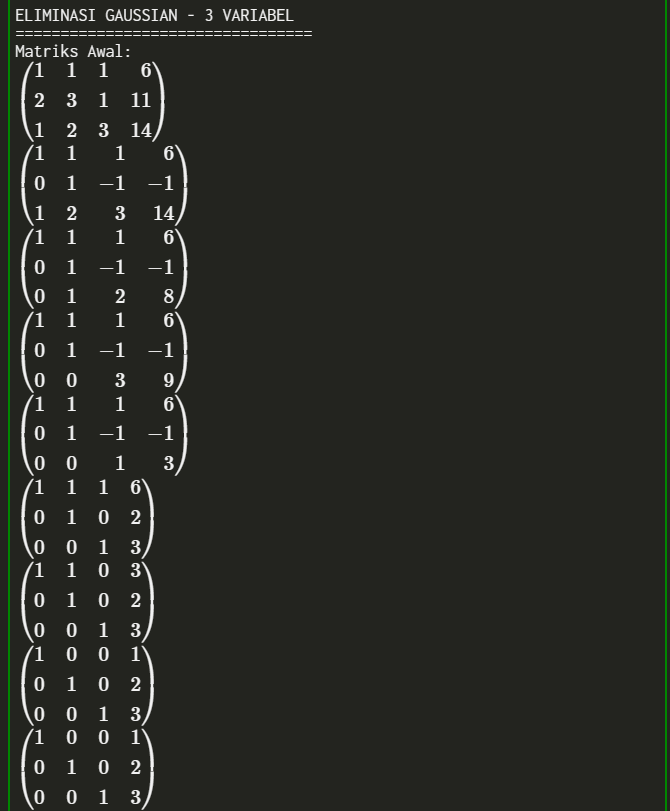

In [9]:
from IPython.display import Image
Image("EGV3.png")

In [ ]:
print("ELIMINASI GAUSSIAN - 3 VARIABEL")
print("=================================")

A = matrix([
[1,1,1,6],
[2,3,1,11],
[1,2,3,14]
])

print("Matriks Awal:")
show(A)

# R2 → R2 - 2R1
A = A.with_added_multiple_of_row(1,0,-2)
print("R2 → R2 - 2R1 (Baris 2 dikurangi 2 kali Baris 1)")
show(A)

# R3 → R3 - R1
A = A.with_added_multiple_of_row(2,0,-1)
print("R3 → R3 - R1 (Baris 3 dikurangi Baris 1)")
show(A)

# R3 → R3 - R2
A = A.with_added_multiple_of_row(2,1,-1)
print("R3 → R3 - R2 (Baris 3 dikurangi Baris 2)")
show(A)

# R3 → (1/3)R3
A = A.with_rescaled_row(2,1/3)
print("R3 → (1/3)R3 (Baris 3 dibagi 3)")
show(A)

# R2 → R2 + R3
A = A.with_added_multiple_of_row(1,2,1)
print("R2 → R2 + R3 (Baris 2 ditambah Baris 3)")
show(A)

# R1 → R1 - R3
A = A.with_added_multiple_of_row(0,2,-1)
print("R1 → R1 - R3 (Baris 1 dikurangi Baris 3)")
show(A)

# R1 → R1 - R2
A = A.with_added_multiple_of_row(0,1,-1)
print("R1 → R1 - R2 (Baris 1 dikurangi Baris 2)")
show(A)

print("HASIL AKHIR:")
show(A)

#### LANGKAH 1: Eliminasi kolom pertama (baris 2)

**Operasi 1: R2 = R2 - 2×R1**

R2: (2 3 1 | 11) - 2×(1 1 1 | 6)

= (2-2, 3-2, 1-2 | 11-12)

= (0 1 -1 | -1)

#### LANGKAH 2: Eliminasi kolom pertama (baris 3)

**Operasi: R3 = R3 - R1**

R3: (1 2 3 | 14) - (1 1 1 | 6)

= (1-1, 2-1, 3-1 | 14-6)

= (0 1 2 | 8)

#### LANGKAH 3: Eliminasi kolom kedua (baris 3)

**Operasi: R3 = R3 - R2**

R3: (0 1 2 | 8) - (0 1 -1 | -1)

= (0, 1-1, 2-(-1) | 8-(-1))

= (0 0 3 | 9)

#### LANGKAH 4: Rescaling baris 3

**Operasi: R3 = R3 ÷ 3**

R3: (0 0 3 | 9) ÷ 3

= (0 0 1 | 3)

#### LANGKAH 5: Substitusi Mundur - Eliminasi kolom ketiga

**Operasi 1: R2 = R2 + R3**

R2: (0 1 -1 | -1) + (0 0 1 | 3)

= (0 1 0 | 2)

Operasi 2: R1 = R1 - R3

R1: (1 1 1 | 6) - (0 0 1 | 3)

= (1 1 0 | 3)

#### LANGKAH 6: Substitusi Mundur - Eliminasi kolom kedua

**Operasi: R1 = R1 - R2**

R1: (1 1 0 | 3) - (0 1 0 | 2)

= (1 0 0 | 1)

**SOLUSI:**

x = 1, y = 2, z = 3

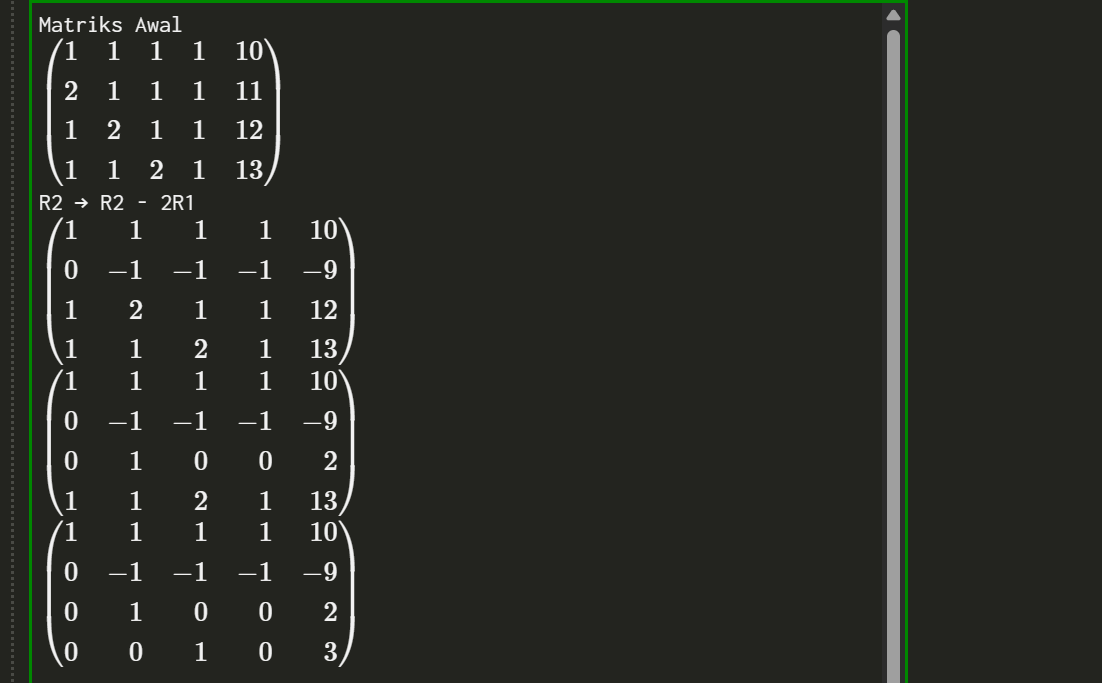

In [8]:
from IPython.display import Image
Image("EGV4c1.png")

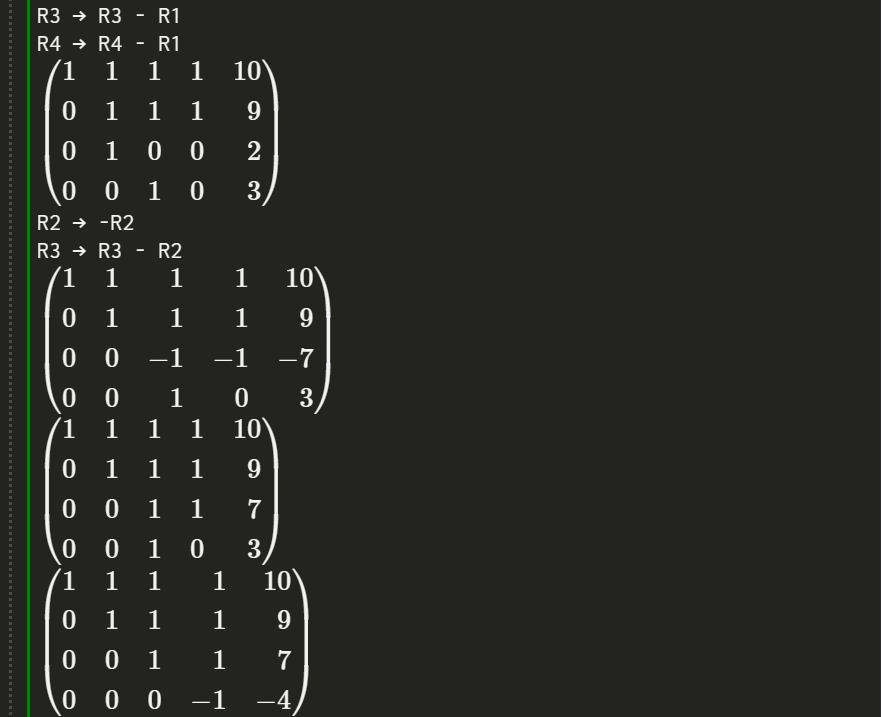

In [10]:
from IPython.display import Image
Image("EGV4c2.png")

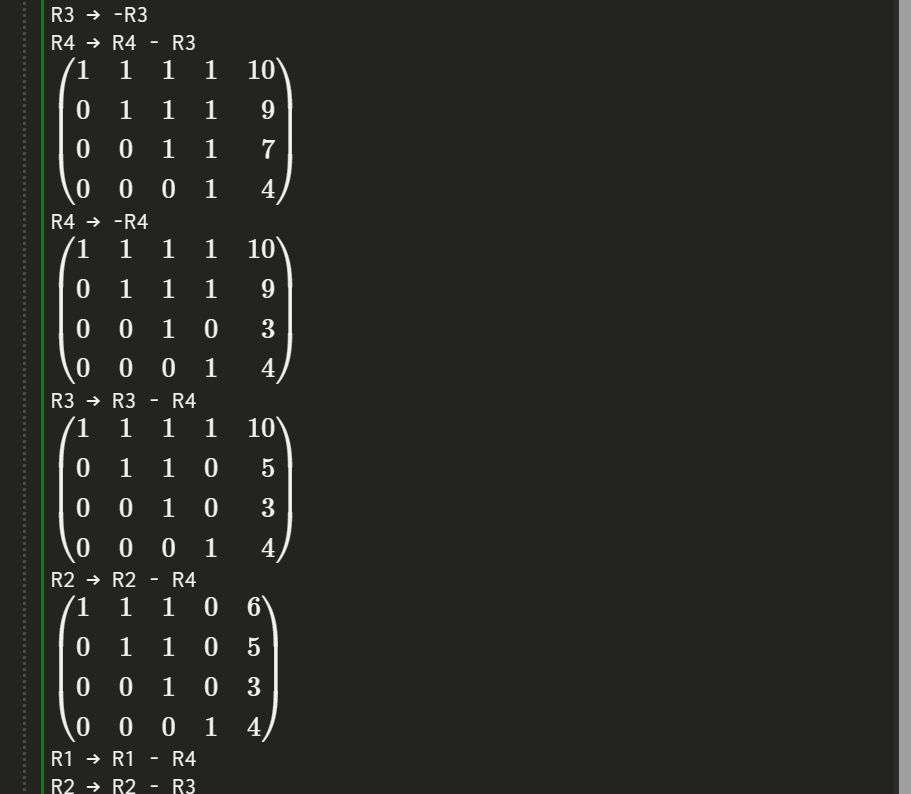

In [11]:
from IPython.display import Image
Image("EGV4c3.png")

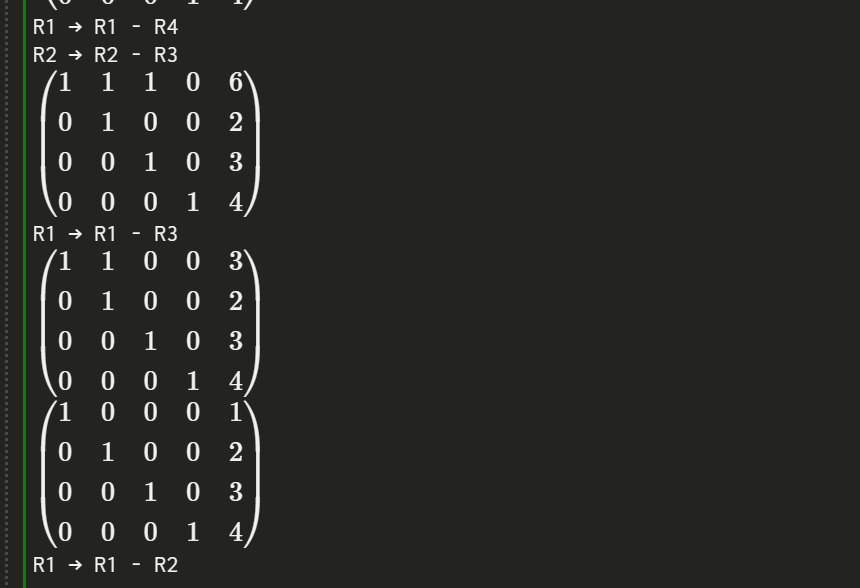

In [12]:
from IPython.display import Image
Image("EGV4c4.png")

In [ ]:
B = matrix([
[1,1,1,1,10],
[2,1,1,1,11],
[1,2,1,1,12],
[1,1,2,1,13]
])

print("Matriks Awal")
show(B)

B = B.with_added_multiple_of_row(1,0,-2)
print("R2 → R2 - 2R1")
show(B)

B = B.with_added_multiple_of_row(2,0,-1)
print("R3 → R3 - R1")
show(B)

B = B.with_added_multiple_of_row(3,0,-1)
print("R4 → R4 - R1")
show(B)

B = B.with_rescaled_row(1,-1)
print("R2 → -R2")
show(B)

B = B.with_added_multiple_of_row(2,1,-1)
print("R3 → R3 - R2")
show(B)

B = B.with_rescaled_row(2,-1)
print("R3 → -R3")
show(B)

B = B.with_added_multiple_of_row(3,2,-1)
print("R4 → R4 - R3")
show(B)

B = B.with_rescaled_row(3,-1)
print("R4 → -R4")
show(B)

B = B.with_added_multiple_of_row(2,3,-1)
print("R3 → R3 - R4")
show(B)

B = B.with_added_multiple_of_row(1,3,-1)
print("R2 → R2 - R4")
show(B)

B = B.with_added_multiple_of_row(0,3,-1)
print("R1 → R1 - R4")
show(B)

B = B.with_added_multiple_of_row(1,2,-1)
print("R2 → R2 - R3")
show(B)

B = B.with_added_multiple_of_row(0,2,-1)
print("R1 → R1 - R3")
show(B)

B = B.with_added_multiple_of_row(0,1,-1)
print("R1 → R1 - R2")
show(B)

### Matriks Awal
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
2 & 1 & 1 & 1 & 11 \\
1 & 2 & 1 & 1 & 12 \\
1 & 1 & 2 & 1 & 13
\end{pmatrix}
$$

**Operasi:** $R2 \to R2 - 2R1$
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & -1 & -1 & -1 & -9 \\
1 & 2 & 1 & 1 & 12 \\
1 & 1 & 2 & 1 & 13
\end{pmatrix}
$$

(Langkah selanjutnya terlihat di gambar: $R3 \to R3 - R1$ dan $R4 \to R4 - R1$)
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & -1 & -1 & -1 & -9 \\
0 & 1 & 0 & 0 & 2 \\
0 & 0 & 1 & 0 & 3
\end{pmatrix}
$$

---

**Operasi:** $R3 \to R3 - R1$, $R4 \to R4 - R1$ (Lanjutan normalisasi kolom 1)
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & 1 & 1 & 1 & 9 \\
0 & 1 & 0 & 0 & 2 \\
0 & 0 & 1 & 0 & 3
\end{pmatrix}
$$
*(Catatan: Pada gambar, baris 2似乎 sudah dikalikan -1 menjadi positif)*

**Operasi:** $R2 \to -R2$, $R3 \to R3 - R2$
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & 1 & 1 & 1 & 9 \\
0 & 0 & -1 & -1 & -7 \\
0 & 0 & 1 & 0 & 3
\end{pmatrix}
$$

(Langkah implisit: $R3 \to -R3$)
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & 1 & 1 & 1 & 9 \\
0 & 0 & 1 & 1 & 7 \\
0 & 0 & 1 & 0 & 3
\end{pmatrix}
$$

(Langkah implisit: $R4 \to R4 - R3$)
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & 1 & 1 & 1 & 9 \\
0 & 0 & 1 & 1 & 7 \\
0 & 0 & 0 & -1 & -4
\end{pmatrix}
$$

---

**Operasi:** $R3 \to -R3$, $R4 \to R4 - R3$
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & 1 & 1 & 1 & 9 \\
0 & 0 & 1 & 1 & 7 \\
0 & 0 & 0 & 1 & 4
\end{pmatrix}
$$

**Operasi:** $R4 \to -R4$ (Sebenarnya langkah ini membuat R4 positif, dan langkah selanjutnya merapikan R3)
$$
\begin{pmatrix}
1 & 1 & 1 & 1 & 10 \\
0 & 1 & 1 & 1 & 9 \\
0 & 0 & 1 & 0 & 3 \\
0 & 0 & 0 & 1 & 4
\end{pmatrix}
$$

**Operasi:** $R3 \to R3 - R4$ (dan operasi baris lainnya untuk membersihkan kolom 4)
$$
\begin{pmatrix}
1 & 1 & 1 & 0 & 6 \\
0 & 1 & 1 & 0 & 5 \\
0 & 0 & 1 & 0 & 3 \\
0 & 0 & 0 & 1 & 4
\end{pmatrix}
$$

---

**Operasi:** $R1 \to R1 - R4$, $R2 \to R2 - R3$
$$
\begin{pmatrix}
1 & 1 & 1 & 0 & 6 \\
0 & 1 & 0 & 0 & 2 \\
0 & 0 & 1 & 0 & 3 \\
0 & 0 & 0 & 1 & 4
\end{pmatrix}
$$

**Operasi:** $R1 \to R1 - R3$
$$
\begin{pmatrix}
1 & 1 & 0 & 0 & 3 \\
0 & 1 & 0 & 0 & 2 \\
0 & 0 & 1 & 0 & 3 \\
0 & 0 & 0 & 1 & 4
\end{pmatrix}
$$

(Langkah implisit menuju matriks identitas)
$$
\begin{pmatrix}
1 & 0 & 0 & 0 & 1 \\
0 & 1 & 0 & 0 & 2 \\
0 & 0 & 1 & 0 & 3 \\
0 & 0 & 0 & 1 & 4
\end{pmatrix}
$$

**Operasi Terakhir:** $R1 \to R1 - R2$

**Solusi:**
w = 1, x = 2, y = 3, z = 4